# P1 · Read, run, save, and restore

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.18 · Read, run, save, and restore

Configuration constructs the architecture; a state dictionary supplies its stored tensors. Verify the loaded model with the same input.

**Prerequisites:** Generate one token at a time

**Predict:** What is required to load a state dictionary for inference?

**Mental model:** The final notebook combines the tensor skills in the course's actual tiny architecture. The model is initialized afresh so the experiment cannot alter the recorded checkpoint.

<a id="pytorch-practice"></a>

<a data-compat-cell="p1-practice-one-layer-at-sprout-s-size"></a>

### Why this operation exists

The final notebook combines the tensor skills in the course's actual tiny architecture. The model is initialized afresh so the experiment cannot alter the recorded checkpoint.

Configuration describes which layers and shapes to construct. A state dictionary supplies the tensors that fit that architecture.

A saved prediction function should reproduce its outputs when loaded into a matching model and evaluated on the same input.

Resuming a training run asks for more than weights: the optimizer and relevant run state matter as well. Distinguish those two saving goals.

This capstone proves that you can operate and inspect the model. It does not claim that a single training step produces meaningful language.

### Included reference model

The current Unit 1 architecture. A descriptive alias names it `TinyTransformer`. This creates fresh parameters; it does not load or change a recorded checkpoint.

In [3]:
#@title Reference architecture (expand to inspect) { display-mode: "form" }
"""Our tiny transformer: 9,417 learned numbers that predict the next character of Shakespeare.

It reads up to 32 characters of text and gives a probability to each of the 65 characters that could come next. Writing is
that prediction in a loop: pick a character, append it, slide the 32-character window, and predict again. (The class is
called Prompter for the course's file names; learners meet it as "our tiny transformer".)

The architecture is the "10k" configuration of maxpolaczuk/tiny-character-transformer (a 1-block, 2-head character GPT on Tiny
Shakespeare). The code here is written fresh for the course (that repository has no licence, so none of its code or weights
are copied): every line is one the course teaches.

    characters ─► token table (65 × 28) + position table (32 × 28)        lookup:      what, and where
               ─► one block: LayerNorm ─► 2-head causal attention ─► +    look back:   which earlier letters matter
                             LayerNorm ─► feed-forward 28 → 56 → 28 ─► +  think:       transform each row on its own
               ─► final LayerNorm ─► readout with the token table again   score all 65 characters
               ─► softmax                                                  probabilities for the next character

Parameters: token table 1,820 · positions 896 · block 6,580 (two LayerNorms 112, q|k|v 2,436, attention out 812,
feed-forward 1,624 + 1,596) · final LayerNorm 56 · readout bias 65 = 9,417.
"""

import math
from dataclasses import asdict, dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F


@dataclass(frozen=True)
class Config:
    vocab_size: int = 65    # every distinct character in Tiny Shakespeare
    block_size: int = 32    # how many characters the model can read at once (its context)
    d_model: int = 28       # how many numbers describe one character in one place (a row)
    n_head: int = 2         # attention heads, each looking with 28 / 2 = 14 numbers
    d_ff: int = 56          # the feed-forward network's hidden width (2 × d_model)
    n_layer: int = 1        # transformer blocks

    def to_dict(self):
        return asdict(self)


class Tokenizer:
    """One id per character, in sorted order: '\\n' is 0, ' ' is 1, … 'z' is 64."""

    def __init__(self, text: str):
        self.chars = sorted(set(text))
        self.stoi = {c: i for i, c in enumerate(self.chars)}

    def encode(self, s: str) -> list[int]:
        return [self.stoi[c] for c in s]

    def decode(self, ids) -> str:
        return "".join(self.chars[int(i)] for i in ids)


class CausalSelfAttention(nn.Module):
    """Each row asks a question (q), every earlier row offers a label (k) and a message (v). A row reads the messages of the
    rows whose labels match its question best, never a row to its right."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.n_head, self.head_dim = cfg.n_head, cfg.d_model // cfg.n_head
        self.qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model)     # q, k and v for both heads in one matrix
        self.proj = nn.Linear(cfg.d_model, cfg.d_model)        # mix the heads' results back into one row
        mask = torch.tril(torch.ones(cfg.block_size, cfg.block_size))
        self.register_buffer("mask", mask.view(1, 1, cfg.block_size, cfg.block_size), persistent=False)

    def forward(self, x, keep=None):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = (t.view(B, T, self.n_head, self.head_dim).transpose(1, 2) for t in (q, k, v))
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)          # how well each question matches each label
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))   # no peeking at the future
        att = F.softmax(att, dim=-1)                                          # shares that add up to 1
        if keep is not None:
            keep["attn"] = att.detach()
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)            # each row: a weighted mix of messages
        return self.proj(y)


class Block(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.ff = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_ff), nn.GELU(), nn.Linear(cfg.d_ff, cfg.d_model))

    def forward(self, x, keep=None):
        x = x + self.attn(self.ln1(x), keep)    # look back, and add what was found to the row
        x = x + self.ff(self.ln2(x))            # think about each row on its own, and add that too
        return x


class Prompter(nn.Module):
    def __init__(self, cfg: Config = Config()):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)    # one learned row per character
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.d_model)    # one learned row per place 0 … 31
        self.blocks = nn.Sequential(*[Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head_bias = nn.Parameter(torch.zeros(cfg.vocab_size))  # the readout reuses tok_emb (tied); only its bias is new
        self.apply(self._init)

    @staticmethod
    def _init(m):
        # small random numbers (σ = 0.02), so the untrained model's guesses are nearly even: its first loss is about
        # ln 65 = 4.17, the loss of a uniform guess over 65 characters
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None, keep=None):
        T = idx.size(1)
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))   # what + where
        for b in self.blocks:
            x = b(x, keep)
        x = self.ln_f(x)
        logits = x @ self.tok_emb.weight.T + self.head_bias                         # a score for every character
        loss = None if targets is None else F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, n, temperature=1.0, generator=None):
        for _ in range(n):
            logits, _ = self(idx[:, -self.cfg.block_size:])
            probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
            nxt = torch.multinomial(probs, 1, generator=generator)
            idx = torch.cat([idx, nxt], dim=1)
        return idx


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

TinyTransformer = Prompter

### Follow the values

Construct the current architecture and count its unique learned elements. The count is 9,417, with the configuration displayed beside it.

Pass a batch of one four-token sequence and its shifted targets. The logits have shape one by four by sixty-five, and the loss is scalar.

Backpropagate and inspect the token-table gradient. Its shape matches the table's sixty-five entries of twenty-eight features.

Let AdamW perform one update, then compare the embedding against a copied pre-update snapshot. The comparison confirms that optimization changed stored values.

Save and reload the state into a matching fresh model. The same input now produces identical CPU outputs in this experiment, with maximum absolute difference zero.

In [4]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
import io
torch.manual_seed(11 if change else 7)
model = TinyTransformer()
show("Current architecture", {"parameters": sum(p.numel() for p in model.parameters()), "config": model.cfg.to_dict()})
ids = torch.tensor([[1,2,3,4]])
targets = torch.tensor([[2,3,4,5]])
logits, loss = model(ids, targets)
show("Forward contract", {"logits shape": list(logits.shape), "loss": loss.item()})
before = model.tok_emb.weight.detach().clone()
optimizer = torch.optim.AdamW(model.parameters(), lr=.001)
optimizer.zero_grad(set_to_none=True)
loss.backward()
show("Embedding gradient shape", model.tok_emb.weight.grad.shape)
optimizer.step()
show("Embedding changed", not torch.equal(before, model.tok_emb.weight))
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
buffer.seek(0)
restored = TinyTransformer(model.cfg)
restored.load_state_dict(torch.load(buffer, map_location="cpu", weights_only=True))
model.eval(); restored.eval()
with torch.no_grad():
    expected, _ = model(ids)
    actual, _ = restored(ids)
show("Reload maximum absolute difference", (actual-expected).abs().max())
torch.testing.assert_close(actual, expected)

Current architecture: {"parameters": 9417, "config": {"vocab_size": 65, "block_size": 32, "d_model": 28, "n_head": 2, "d_ff": 56, "n_layer": 1}}
Forward contract: {"logits shape": [1, 4, 65], "loss": 4.246893405914307}


Embedding gradient shape: [65, 28]
Embedding changed: true
Reload maximum absolute difference: 0.0
  shape [] · torch.float32 · cpu


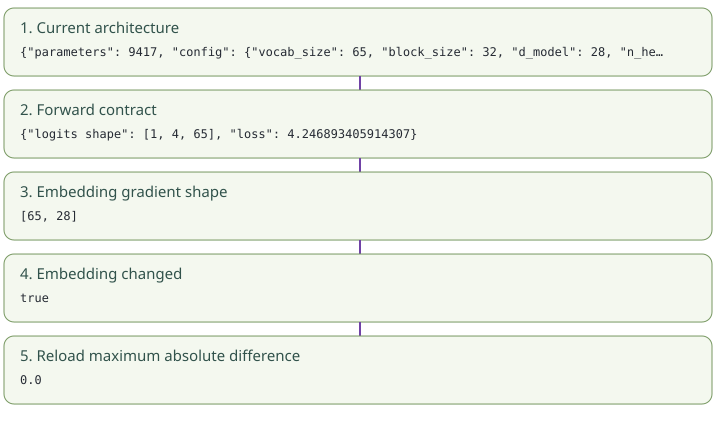

In [5]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

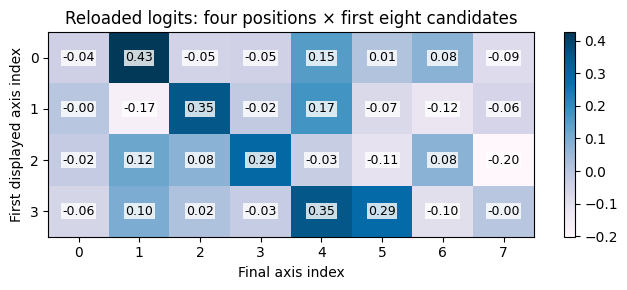

In [6]:
image = (actual[0,:,:8]).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Reloaded logits: four positions × first eight candidates'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### Read the implementation

The notebook embeds the current reference model, keeping the experiment independent of a repository clone. Its source is checked against the course model during generation.

Use an explicit seed before construction and keep the input and target tensors visible. The learned values here are newly initialized, not the trained Unit One checkpoint.

Clone the detached pre-update weight when preserving a comparison snapshot. Merely saving a second reference would not protect the earlier values.

Save the state dictionary and load it into the matching architecture with weights only and an explicit CPU mapping. A vocabulary mapping must be preserved alongside weights for decoded text.

Compare outputs after loading, and inspect missing or unexpected state keys instead of hiding an architecture mismatch. The training unit develops complete resumable checkpoints.

### Change one thing

**Initialize with seed 11**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [7]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
import io
torch.manual_seed(11 if change else 7)
model = TinyTransformer()
show("Current architecture", {"parameters": sum(p.numel() for p in model.parameters()), "config": model.cfg.to_dict()})
ids = torch.tensor([[1,2,3,4]])
targets = torch.tensor([[2,3,4,5]])
logits, loss = model(ids, targets)
show("Forward contract", {"logits shape": list(logits.shape), "loss": loss.item()})
before = model.tok_emb.weight.detach().clone()
optimizer = torch.optim.AdamW(model.parameters(), lr=.001)
optimizer.zero_grad(set_to_none=True)
loss.backward()
show("Embedding gradient shape", model.tok_emb.weight.grad.shape)
optimizer.step()
show("Embedding changed", not torch.equal(before, model.tok_emb.weight))
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
buffer.seek(0)
restored = TinyTransformer(model.cfg)
restored.load_state_dict(torch.load(buffer, map_location="cpu", weights_only=True))
model.eval(); restored.eval()
with torch.no_grad():
    expected, _ = model(ids)
    actual, _ = restored(ids)
show("Reload maximum absolute difference", (actual-expected).abs().max())
torch.testing.assert_close(actual, expected)

Current architecture: {"parameters": 9417, "config": {"vocab_size": 65, "block_size": 32, "d_model": 28, "n_head": 2, "d_ff": 56, "n_layer": 1}}
Forward contract: {"logits shape": [1, 4, 65], "loss": 4.165988445281982}
Embedding gradient shape: [65, 28]
Embedding changed: true
Reload maximum absolute difference: 0.0
  shape [] · torch.float32 · cpu


### A useful distinction

Weights alone preserve inference state; exact training continuation also needs optimizer, configuration, step and relevant random state.

In [8]:
with torch.no_grad():
    generated = restored.generate(ids, 4, generator=torch.Generator().manual_seed(7))
assert generated.shape == (1,8)
print("Generated IDs from a model after one update, not a trained-language claim:", generated.tolist())
try:
    restored(torch.tensor([[65]]))
except IndexError:
    print("The embedding rejects an ID outside the vocabulary.")

Generated IDs from a model after one update, not a trained-language claim: [[1, 2, 3, 4, 16, 58, 2, 5]]
The embedding rejects an ID outside the vocabulary.


### ✋ Your turn

For the current TinyTransformer, put its unique parameter count in answer.

In [9]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 9417, 'Weights alone preserve inference state; exact training continuation also needs optimizer, configuration, step and relevant random state.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [10]:
#@title Show a solution { display-mode: "form" }
answer = sum(p.numel() for p in TinyTransformer().parameters())

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 9417, 'Weights alone preserve inference state; exact training continuation also needs optimizer, configuration, step and relevant random state.'
    print("✓ right:", answer)

✓ right: 9417


### Reconnect to the transformer

You have now followed IDs through lookups, normalized branches, attention, feed-forward transformations and a tied vocabulary readout. Every intermediate has a shape contract.

You can distinguish logits, loss, gradients and updated parameters. They are related stages rather than interchangeable measurements of learning.

The maths collection derives the calculations you have executed. Unit One reconnects them into a complete model, and Unit Two develops the training workflow and its evidence.

Phyll scales and modifies parts of the architecture. Its larger tensors, padding rules, dropout and tokenizer require explicit comparisons, while these programming foundations transfer.

Return to a chapter when a new line of model code feels opaque. Predict the values and axes first, run a small case, and check the result.

```python
model = TinyTransformer(config)
model.load_state_dict(saved_weights)
model.eval()
with torch.no_grad():
    logits, _ = model(ids)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What is required to load a state dictionary for inference?

<details><summary>Check your explanation</summary>

A matching architecture and configuration. Weights alone preserve inference state; exact training continuation also needs optimizer, configuration, step and relevant random state.

</details>